<a href="https://colab.research.google.com/github/Christi049/Group-fairness-in-IM/blob/main/Copy2_Group_fairness_in_IM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install gurobi

In [1]:
!pip install -q "gurobipy>=10"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 56.9 MB/s eta 0:00:00


In [2]:
import gurobipy as gp
print(gp.gurobi.version())

(13, 0, 2)


In [3]:
import gurobipy as gp

env = gp.Env()
env.start()

print("Gurobi environment started successfully!")

Restricted license - for non-production use only - expires 2027-11-29
Gurobi environment started successfully!


In [4]:
!grep -n "solver =" /content/fair_influmax_code_release/check_fairness.py

grep: /content/fair_influmax_code_release/check_fairness.py: No such file or directory


In [5]:
!git clone https://github.com/bwilder0/fair_influmax_code_release.git
%cd fair_influmax_code_release

Cloning into 'fair_influmax_code_release'...
remote: Enumerating objects: 57, done.
remote: Total 57 (delta 0), reused 0 (delta 0), pack-reused 57 (from 1)
Receiving objects: 100% (57/57), 979.78 KiB | 3.14 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/fair_influmax_code_release


In [6]:
!ls

algorithms.py			  check_fairness.py  networks	utils.py
check_fairness_intersectional.py  icm.py	     README.md


fix old version - change every instance of g.node[v][attribute] to g.nodes[v][attribute]

In [7]:
!grep -rn '\.node\[' /content/fair_influmax_code_release --include=*.py

/content/fair_influmax_code_release/check_fairness_intersectional.py:71:            if 'race' not in g.node[v]:
/content/fair_influmax_code_release/check_fairness_intersectional.py:89:            nvalues = len(np.unique([g.node[v][attribute] for v in g.nodes()]))
/content/fair_influmax_code_release/check_fairness_intersectional.py:92:                    if np.isnan(g.node[v][attribute]):
/content/fair_influmax_code_release/check_fairness_intersectional.py:93:                        g.node[v][attribute] = nvalues
/content/fair_influmax_code_release/check_fairness_intersectional.py:96:                    g.node[v][attribute] = attribute + '_' + str(int(g.node[v][attribute]))
/content/fair_influmax_code_release/check_fairness_intersectional.py:97:            nvalues = len(np.unique([g.node[v][attribute] for v in g.nodes()]))
/content/fair_influmax_code_release/check_fairness_intersectional.py:132:            values = np.unique([g.node[v][attribute] for v in g.nodes()])
/content/fair_influ

In [8]:
!grep -rl '\.node\[' /content/fair_influmax_code_release --include=*.py | xargs sed -i 's/\.node\[/.nodes[/g'

In [9]:
!grep -rn '\.node\[' /content/fair_influmax_code_release --include=*.py

fix old version - change every instance of np.int to int

In [10]:
!grep -rn 'np\.\(int\|float\|bool\|object\)\b' /content/fair_influmax_code_release --include=*.py

/content/fair_influmax_code_release/icm.py:151:        G_array = np.zeros((n, max_degree), dtype=np.int)
/content/fair_influmax_code_release/icm.py:188:        G = np.zeros(g.number_of_edges(), dtype=np.int)
/content/fair_influmax_code_release/icm.py:192:        start_pos = np.zeros(len(g)+1, dtype=np.int)


In [11]:
!grep -rl 'np\.int\b' /content/fair_influmax_code_release --include=*.py | xargs sed -i 's/np\.int\b/int/g'

In [12]:
!grep -rn 'np\.\(int\|float\|bool\|object\)\b' /content/fair_influmax_code_release --include=*.py

In [13]:
!sed -i 's/budget = 15/budget = 25/' /content/fair_influmax_code_release/check_fairness.py

In [14]:
!sed -i "s/solver = 'md'/solver = 'gurobi'/" /content/fair_influmax_code_release/check_fairness.py

Reducing the number of networks and attributes

In [15]:
!grep -n "solver =" /content/fair_influmax_code_release/check_fairness.py

40:solver = 'gurobi'


with budget = 25

In [16]:
!python check_fairness.py

Budget: 25
['spa_500_0', 'spa_500_1', 'spa_500_2', 'spa_500_3', 'spa_500_4', 'spa_500_5', 'spa_500_6', 'spa_500_7', 'spa_500_8', 'spa_500_9']
spa_500_0 0
Restricted license - for non-production use only - expires 2027-11-29
fair: 0.2275383815470201, greedy: 0.6901716889333608
fair: 0.033151113996923436, greedy: 0.12876909273197187
fair: 0.04026101243919909, greedy: 0.14532339447491247
fair: 0.005767711590279416, greedy: 0.0
fair: 0.011669630735063545, greedy: 0.0718323051171816
spa_500_1 0
fair: 0.2157515090358628, greedy: 0.6522720972405976
fair: 0.07128111894968749, greedy: 0.13533931950019543
fair: 0.05231558422811337, greedy: 0.11213195043796009
fair: 0.03302524309024976, greedy: 0.00977730372668817
fair: 0.02283126662742573, greedy: 0.06741599176778072
spa_500_2 0
fair: 0.21457960920214406, greedy: 0.5676308831551016
fair: 0.020373985237800797, greedy: 0.14506335282651073
fair: 0.020344689941948265, greedy: 0.10319590861430325
fair: 0.04135190455981069, greedy: 0.04406100272445457

In [23]:
from google.colab import files

files.download('/content/fair_influmax_code_release/results_spa.pickle')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
files.download('/content/antelope_valley_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
files.download('/content/antelope_mean_dc_violation.png')
files.download('/content/antelope_min_fraction.png')
files.download('/content/antelope_price_of_fairness.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EXPERIMENTAL RESULTS — 10 ANTELOPE VALLEY NETWORKS

ATTRIBUTE: region
-----------------------------------------------------------------------------------------------
Algorithm           Mean DC Violation     Min Fraction Influenced     Price of Fairness
-----------------------------------------------------------------------------------------------
Greedy                         0.5653                      0.0048                1.0000
DC                             0.2073                      0.0894                1.1276
Maximin                        0.4076                      0.1106                1.1162

ATTRIBUTE: ethnicity
-----------------------------------------------------------------------------------------------
Algorithm           Mean DC Violation     Min Fraction Influenced     Price of Fairness
-----------------------------------------------------------------------------------------------
Greedy                         0.1752                      0.0544                1.0

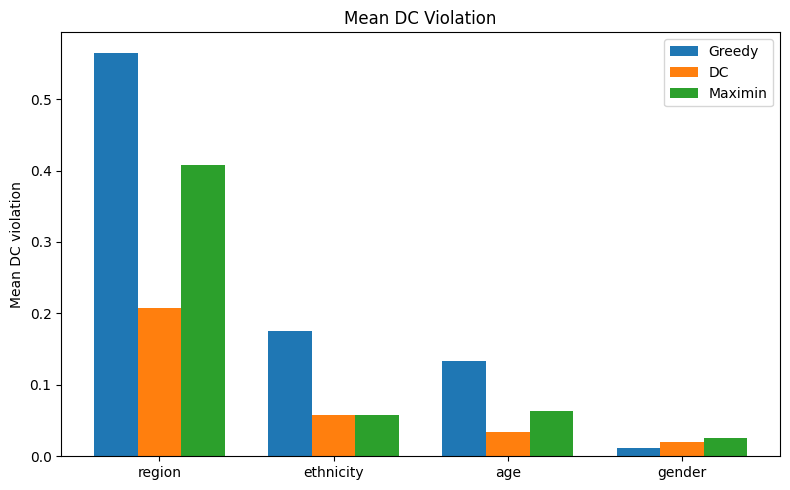

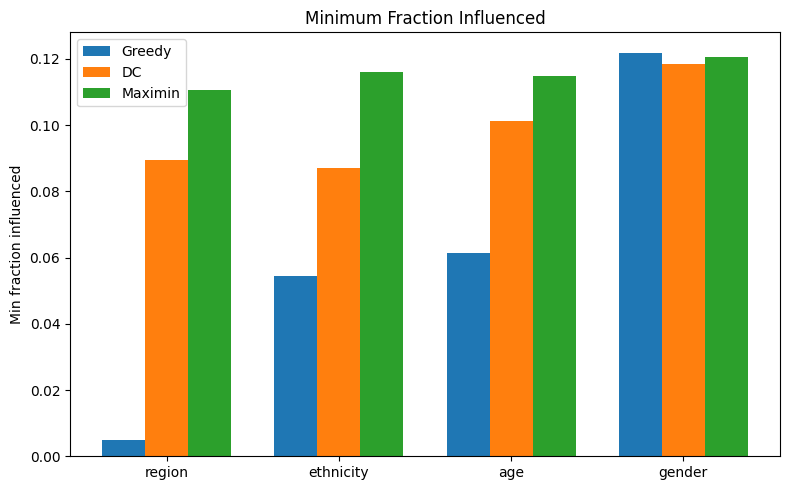

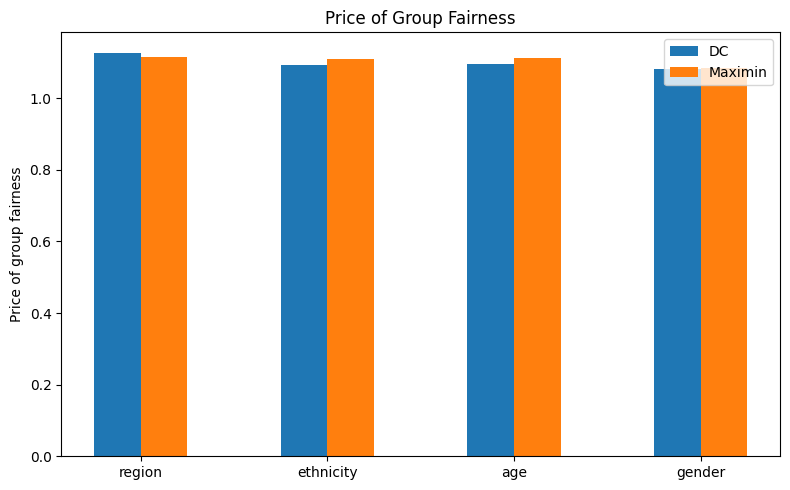


Saved plots:
/content/antelope_mean_dc_violation.png
/content/antelope_min_fraction.png
/content/antelope_price_of_fairness.png


In [22]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# LOAD RESULTS
# ============================================================

alg_values, gr_values, group_size = pickle.load(
    open('/content/fair_influmax_code_release/results_spa.pickle', 'rb')
)

# 10 Antelope Valley networks
graphnames = [f'spa_500_{i}' for i in range(10)]

# Match the attributes shown in the paper
attributes = ['region', 'ethnicity', 'age', 'gender']

# Mapping from pickle names to paper names
algorithms = ['Greedy', 'GR', 'MaxMin-Size']
labels = {
    'Greedy': 'Greedy',
    'GR': 'DC',
    'MaxMin-Size': 'Maximin'
}


# ============================================================
# STORAGE
# ============================================================

mean_violation = {alg: [] for alg in algorithms}
min_fraction = {alg: [] for alg in algorithms}
price_fairness = {alg: [] for alg in algorithms}


# ============================================================
# CALCULATE METRICS
# ============================================================

for attribute in attributes:

    for alg in algorithms:

        violations = []
        min_fracs = []
        pofs = []

        for graphname in graphnames:

            # Optimal group influence values
            all_opt = gr_values[graphname][attribute][0]

            # Algorithm's group influence values
            actual_vals = alg_values[alg][graphname][attribute][0]

            # Group sizes
            sizes = group_size[graphname][attribute][0]

            # ------------------------------------------------
            # 1. Mean DC violation
            # Same definition used in check_fairness.py
            # ------------------------------------------------
            violation = (
                np.clip(all_opt - actual_vals, 0, np.inf)
                / all_opt
            )

            violations.append(violation.mean())

            # ------------------------------------------------
            # 2. Minimum fraction influenced
            # ------------------------------------------------
            frac = actual_vals / sizes
            min_fracs.append(frac.min())

            # ------------------------------------------------
            # 3. Price of fairness
            #
            # Greedy total influence / algorithm total influence
            # ------------------------------------------------
            greedy_vals = alg_values['Greedy'][graphname][attribute][0]

            pof = greedy_vals.sum() / actual_vals.sum()
            pofs.append(pof)

        # Average across the 10 networks
        mean_violation[alg].append(np.mean(violations))
        min_fraction[alg].append(np.mean(min_fracs))
        price_fairness[alg].append(np.mean(pofs))


# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 95)
print("EXPERIMENTAL RESULTS — 10 ANTELOPE VALLEY NETWORKS")
print("=" * 95)

rows = []

for i, attribute in enumerate(attributes):

    print(f"\nATTRIBUTE: {attribute}")
    print("-" * 95)

    print(
        f"{'Algorithm':<15}"
        f"{'Mean DC Violation':>22}"
        f"{'Min Fraction Influenced':>28}"
        f"{'Price of Fairness':>22}"
    )

    print("-" * 95)

    for alg in algorithms:

        mv = mean_violation[alg][i]
        mf = min_fraction[alg][i]
        pof = price_fairness[alg][i]

        print(
            f"{labels[alg]:<15}"
            f"{mv:>22.4f}"
            f"{mf:>28.4f}"
            f"{pof:>22.4f}"
        )

        rows.append({
            'Attribute': attribute,
            'Algorithm': labels[alg],
            'Mean DC Violation': mv,
            'Min Fraction Influenced': mf,
            'Price of Fairness': pof
        })


# ============================================================
# COMPLETE DATAFRAME
# ============================================================

results_df = pd.DataFrame(rows)

print("\n")
print("=" * 95)
print("COMPLETE RESULTS TABLE")
print("=" * 95)

print(results_df.to_string(index=False))

# Save results
results_df.to_csv(
    '/content/antelope_valley_results.csv',
    index=False
)

print("\nSaved results to:")
print("/content/antelope_valley_results.csv")


# ============================================================
# VISUALIZATION 1 — MEAN DC VIOLATION
# ============================================================

x = np.arange(len(attributes))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

for i, alg in enumerate(algorithms):

    ax.bar(
        x + (i - 1) * width,
        mean_violation[alg],
        width,
        label=labels[alg]
    )

ax.set_xticks(x)
ax.set_xticklabels(attributes)

ax.set_ylabel('Mean DC violation')
ax.set_title('Mean DC Violation')

ax.legend()

plt.tight_layout()

plt.savefig(
    '/content/antelope_mean_dc_violation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# VISUALIZATION 2 — MINIMUM FRACTION INFLUENCED
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

for i, alg in enumerate(algorithms):

    ax.bar(
        x + (i - 1) * width,
        min_fraction[alg],
        width,
        label=labels[alg]
    )

ax.set_xticks(x)
ax.set_xticklabels(attributes)

ax.set_ylabel('Min fraction influenced')
ax.set_title('Minimum Fraction Influenced')

ax.legend()

plt.tight_layout()

plt.savefig(
    '/content/antelope_min_fraction.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# VISUALIZATION 3 — PRICE OF FAIRNESS
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

# We don't want Greedy here because its PoF is always 1
fair_algorithms = ['GR', 'MaxMin-Size']

for i, alg in enumerate(fair_algorithms):

    ax.bar(
        x + (i - 0.5) * width,
        price_fairness[alg],
        width,
        label=labels[alg]
    )

ax.set_xticks(x)
ax.set_xticklabels(attributes)

ax.set_ylabel('Price of group fairness')
ax.set_title('Price of Group Fairness')

ax.legend()

plt.tight_layout()

plt.savefig(
    '/content/antelope_price_of_fairness.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


print("\nSaved plots:")
print("/content/antelope_mean_dc_violation.png")
print("/content/antelope_min_fraction.png")
print("/content/antelope_price_of_fairness.png")